C:\Users\walcker\AppData\Local\Temp\ipykernel_11584\3461316183.py:71: RuntimeWarning: Mean of empty slice
  mean_by_latitude = np.nanmean(data_masked, axis=2)
C:\python\anaconda3\envs\Amibea\lib\site-packages\numpy\lib\nanfunctions.py:1746: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)
C:\python\anaconda3\envs\Amibea\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


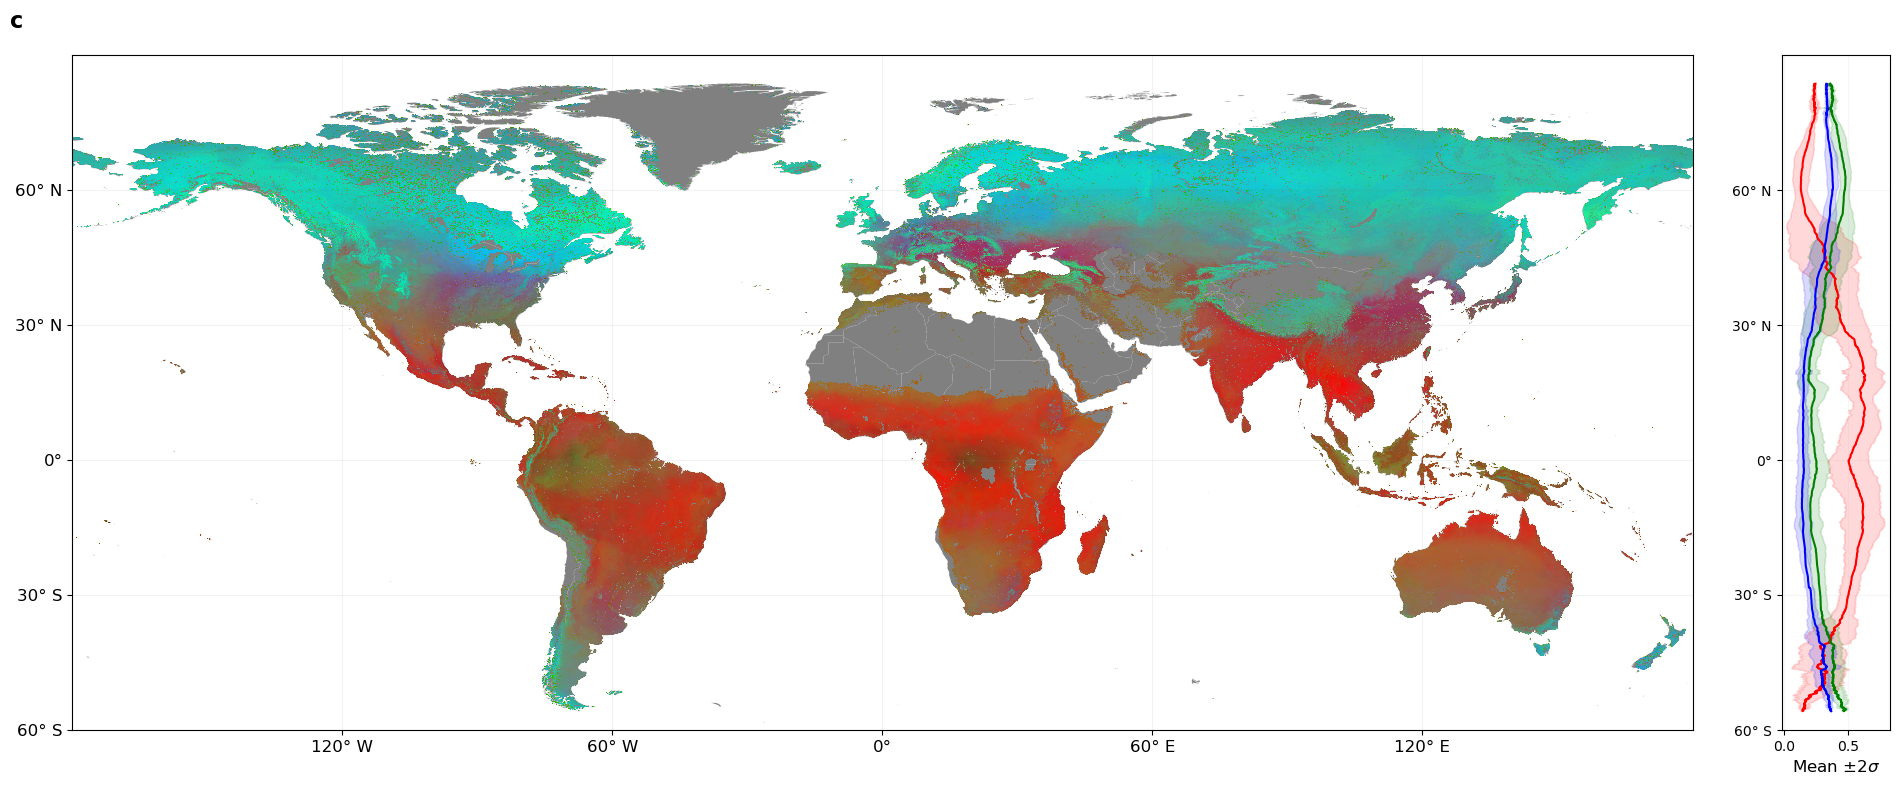

In [3]:
import rasterio
from rasterio.plot import show, reshape_as_image
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import warnings
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

file_path = r"E:\Amibatec\Updated2025\RF\Clusters\meanModel_Clusters123_RF.tif"
world_boundaries_shp = r"E:\Amibatec\Updated2025\world-administrative-boundaries.shp"

warnings.filterwarnings('ignore', message='invalid value encountered in cast', category=RuntimeWarning)

with rasterio.open(file_path) as src:
    data = src.read((1, 2, 3))
    data_masked = src.read(masked=True)
    
    fig = plt.figure(figsize=(20, 9))
    fig.text(x=0.03, y=0.95, s='c', fontsize=16, fontweight='bold', ha='left', va='top')
    gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[15, 1],wspace=0.1, hspace=0.0) # wspace: espace entre les colonnes
    ax_map = fig.add_subplot(gs[0, 0])
    ax_profile = fig.add_subplot(gs[0, 1], sharey=ax_map)

    # Plot de gauche
    world = gpd.read_file(world_boundaries_shp)
    world = world.to_crs(src.crs)
    world.plot(ax=ax_map, color='grey', edgecolor='none', zorder=0)

    image = show(
        data_masked, 
        transform=src.transform, 
        interpolation='nearest', 
        ax=ax_map,               
        zorder=1,
        adjust='linear'
    )

    # Personnalisations
    lat_ticks = [-60, -30, 0, 30, 60]
    lat_labels = ['60° S', '30° S', '0°', '30° N','60° N']
    ax_map.set_yticks(lat_ticks)
    ax_map.set_yticklabels(lat_labels, fontsize=12)
    lon_ticks = [-120, -60, 0, 60, 120]
    lon_labels = ['120° W', '60° W', '0°', '60° E', '120° E']
    ax_map.set_xticks(lon_ticks)
    ax_map.set_xticklabels(lon_labels, fontsize=12)
    ax_map.grid(True, linestyle='-', alpha=0.1, color='grey')
    ax_map.set_ylim(-60, 90)
    ax_map.tick_params(axis='y', labelleft=True, left=True)
    ax_map.set_facecolor('white')
    fig.patch.set_facecolor('white')

    # Légende
    #cluster_patches = [
        #mpatches.Patch(color='red', label='Cluster 1'),
        #mpatches.Patch(color='green', label='Cluster 2'),
        #mpatches.Patch(color='blue', label='Cluster 3')
    #]
    #ax_map.legend(handles=cluster_patches, 
                  #loc='lower left',
                  #fontsize=12,
                  #title_fontsize=12,
                  #frameon=True,
                  #facecolor='white',
                  #edgecolor='black')    

    # Plot de droite
    colors = ['red', 'green', 'blue']
    mean_by_latitude = np.nanmean(data_masked, axis=2)
    std_by_latitude = np.nanstd(data_masked, axis=2)
    height = src.height
    transform = src.transform
    latitudes = np.array([transform * (0, i) for i in range(height)])[:, 1]
    # INVERSION : Latitudes
    #if latitudes[0] > latitudes[-1]:
     #   latitudes = latitudes[::-1]
      #  mean_by_latitude = mean_by_latitude[::-1]
       # std_by_latitude = std_by_latitude[::-1]
    
    for i in range(src.count):
        mean = mean_by_latitude[i]
        std = std_by_latitude[i]
        lower_bound = mean - 2 * std
        upper_bound = mean + 2 * std
        ax_profile.fill_betweenx(
            latitudes,
            lower_bound,
            upper_bound,
            color=colors[i],
            alpha=0.15,
            label=f'Cluster {i+1} ($\pm 2\sigma$)'
        )
        ax_profile.plot(
            mean, 
            latitudes,
            color=colors[i], 
            label=f'Bande {i+1} (Moyenne)',
            linewidth=1.5
        )

    ax_profile.set_xlabel(r'Mean $\pm 2\sigma$', fontsize=12)
    ax_profile.grid(True, linestyle='-', alpha=0.1)

    fig.subplots_adjust(left=0.06, right=0.97, top=0.9, bottom=0.15) # Ajustez ces valeurs

    plt.savefig(r'E:\Amibatec\Updated2025\RF\Clusters\MapClusters.jpeg', dpi=600, bbox_inches='tight')
    plt.show()